<div style="
    background: linear-gradient(90deg, #3F0047, #410075);
    padding: 60px 20px;
    margin: 40px auto;
    border-radius: 18px;
    box-shadow: 0 3px 6px rgba(0, 0, 0, 0.3);
    border: 4px solid #ffffff;
    text-align: center;
    width: 95%;
    box-sizing: border-box;
    overflow: visible;
">
    <h1 style="
        color: white !important;
        font-family: 'Arial Black', Arial, sans-serif;
        font-size: 50px;
        font-weight: 900;
        margin: 0 !important;
        padding: 0 !important;
        line-height: 1 !important;
        text-shadow: 2px 2px 5px rgba(0,0,0,0.7);
        display: block;
    ">
        Customer Churn - LGBM Experiments
    </h1>
</div>


BASE+BIN+DIGIT+ALL_CATS

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
This notebook focuses on the Playground Series S6E3 competition.<br>
</div>

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Import Libraries</b></div>

In [18]:
import numpy as np
import pandas as pd
import math

import matplotlib.pyplot as plt
import seaborn as sns
cmap = sns.cubehelix_palette(as_cmap=True)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from category_encoders import TargetEncoder

from lightgbm import LGBMClassifier
import lightgbm as lgb

from sklearn.metrics import roc_auc_score, roc_curve, auc, brier_score_loss
from sklearn.calibration import CalibrationDisplay
import torch
DEVICE = 'GPU' if torch.cuda.is_available() else 'CPU'
print(f"Using device: {DEVICE}")

Using device: CPU


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Read and Examine Dataset</b></div>

In [19]:
df_train = pd.read_csv(r"Data\train.csv")
df_test = pd.read_csv(r"Data\test.csv")
df_original = pd.read_csv(r"Data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [20]:
df_train = df_train.drop("id", axis=1)
df_original['TotalCharges'] = pd.to_numeric(df_original['TotalCharges'], errors='coerce').astype('float64')

In [21]:
TARGET = "Churn"
categorical_features = (df_train.select_dtypes('object').columns.drop(TARGET).to_list()) + ['SeniorCitizen']
numerical_features = df_train.select_dtypes(include=['int', 'float']).columns.drop('SeniorCitizen').tolist()
base_features = df_train.select_dtypes('object').columns.drop(TARGET).to_list()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Feature Engineering</b></div>

In [22]:
class FeatureEngineering():
    def __init__(self, target, categorical_features, numerical_features, base_features):
        self.target = target
        self.categorical_features = categorical_features
        self.numerical_features = numerical_features
        self.base_features = base_features

    def signal_from_original(self, df, df_original):
        df = df.copy()
        for col in self.categorical_features:
            if col not in df_original.columns:
                continue
    
            means = df_original.groupby(col)[self.target].mean()
            medians = df_original.groupby(col)[self.target].median()
            counts = df_original.groupby(col)[self.target].count()
            
            df[f'{col}_mean'] = df[col].map(means).fillna(df_original[self.target].mean())
            df[f'{col}_median'] = df[col].map(medians).fillna(df_original[self.target].median())
            df[f'{col}_count'] = df[col].map(counts).fillna(0)
        return df

    def binning_features(self, df):
        df = df.copy()
        for col in self.numerical_features:
            df[f'{col}_qcut_5'] = pd.qcut(df[col], q=5, labels=False, duplicates='drop').astype(int)
            df[f'{col}_cut_5'] = pd.cut(df[col], bins=5, labels=False, duplicates='drop').astype(int)
            df[f'{col}_round'] = (df[col] / 20).round().astype(int)
        return df
    
    def frequency_encoding(self, df):
        df = df.copy()
        freq_enc = {col: df[col].value_counts().to_dict() for col in self.base_features}
        for col in self.base_features:
            df[f'{col}_freq'] = df[col].map(freq_enc[col]).fillna(1)
        return df

    def extract_digit_positions(self, df):
        df = df.copy()
        for col in self.numerical_features:
            col_numeric = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
            col_str = col_numeric.astype(str).str.zfill(5)
            
            df[f'{col}_digit_units'] = col_str.str[-1].astype(int)
            df[f'{col}_digit_tens'] = col_str.str[-2].astype(int)
            
            if col_str.str.len().max() >= 3:
                df[f'{col}_digit_hundreds'] = col_str.str[-3].astype(int)
        return df
        
    def encode_all_as_categorical(self, df):
        df = df.copy()
        for col in self.numerical_features:
            df[f'{col}_cat'] = df[col].astype(str)
        return df
        
    def transform_all(self, df):
        # BASE+ALL_CATS
        df = self.encode_all_as_categorical(df)
        return df

In [23]:
#fe = FeatureEngineering(numerical_features=numerical_features)

In [24]:
#df_train_final = fe.transform_all(df=df_train)
#df_test_final = fe.transform_all(df=df_test)

In [25]:
#categorical_features.extend([c for c in df_train_final.columns if '_cat' in c])

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>KFOLD Catboost</b></div>

In [26]:
le = LabelEncoder()
df_train[TARGET] = le.fit_transform(df_train[TARGET])

X = df_train.drop([TARGET], axis=1).copy()
y = df_train[TARGET].copy()
X_test = df_test.drop(['id'], axis=1).copy()

In [31]:
%%time
for col in categorical_features:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

lgbm_params = {
    'objective': 'binary', 
    'metric': 'auc', 
    'n_estimators': 7000,
    'learning_rate': 0.02, 
    'num_leaves': 20,
    'max_depth': 4,
    'min_child_samples': 20,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.1, 
    'reg_lambda': 0.1,
    'random_state': 42,
    'n_jobs': -1, 
    'early_stopping_round': 300, 
    'verbose': -1,
}

n_folds = 5

skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

oof_preds = np.zeros(len(df_train))
y_test_preds = np.zeros(len(df_test))
fold_scores = [] 

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n===== Fold {fold + 1} =====")

    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = LGBMClassifier(**lgbm_params)
    model.fit(
        X_train, 
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(500), lgb.log_evaluation(0)]
    )

    val_probs = model.predict_proba(X_val)[:, 1]
    fold_test_probs = model.predict_proba(X_test)[:, 1]

    oof_preds[val_idx] = val_probs
    y_test_preds += fold_test_probs / n_folds

    score = roc_auc_score(y_val, val_probs)
    fold_scores.append(score)
    print(f"Fold {fold + 1} ROC-AUC Score: {score:.5f}")

total_oof_score = roc_auc_score(y, oof_preds) 
print(f"Overall OOF ROC-AUC: {total_oof_score:.5f}")
print(f"Mean Fold Score: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})")


===== Fold 1 =====
Training until validation scores don't improve for 500 rounds
Fold 1 ROC-AUC Score: 0.91628

===== Fold 2 =====
Training until validation scores don't improve for 500 rounds
Fold 2 ROC-AUC Score: 0.91729

===== Fold 3 =====
Training until validation scores don't improve for 500 rounds
Fold 3 ROC-AUC Score: 0.91660

===== Fold 4 =====
Training until validation scores don't improve for 500 rounds
Fold 4 ROC-AUC Score: 0.91774

===== Fold 5 =====
Training until validation scores don't improve for 500 rounds
Fold 5 ROC-AUC Score: 0.91506
Overall OOF ROC-AUC: 0.91658
Mean Fold Score: 0.91659 (+/- 0.00092)
CPU times: total: 50min 11s
Wall time: 4min 43s


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>ROC CURVE</b></div>

Train AUC score is: 0.9165847946943636


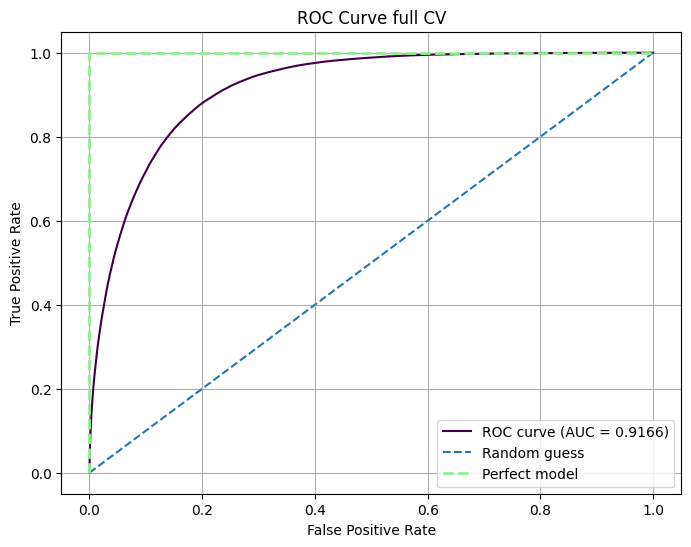

In [32]:
fpr, tpr, thresholds = roc_curve(y, oof_preds)

auc_score = auc(fpr, tpr)
print("Train AUC score is:", auc_score)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.4f})", color='#3F0047')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random guess')
plt.plot([0, 0, 1], [0, 1, 1], color='lightgreen', linestyle='--', linewidth=2, label='Perfect model')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve full CV")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Feature Importance</b></div>

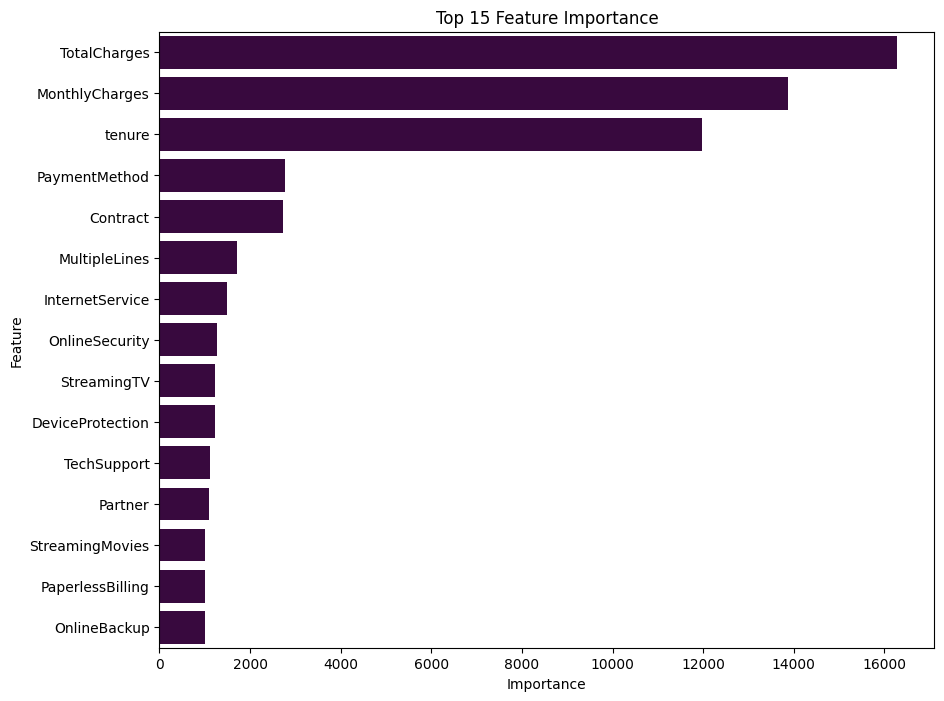

In [33]:
df_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.title("Top 15 Feature Importance") 
ax = sns.barplot(x='Importance', y='Feature', data=df_importance, color='#3F0047')

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Sumission</b></div>

In [34]:
submission = pd.DataFrame({'id': df_test['id'], 'Churn': y_test_preds})
submission.to_csv('submission_lgbm.csv', index=False)
submission.head()

,id,Churn
0,594194,0.066864
1,594195,0.000669
2,594196,0.107846
3,594197,0.003470
4,594198,0.539287
